# level-1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('titanic_boom.xlsx')
df.head()

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
2,113781,Miss,Helen Loraine,Allison,Female,2.0,Family,3,1,Southampton,151.6,0,child
3,113781,Mr,Hudson Joshua Creighton,Allison,Male,30.0,Family,3,1,Southampton,151.6,0,adult
4,113781,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,Female,25.0,Family,3,1,Southampton,151.6,0,teen


1. get the unique values for (gender,pclass,age_category,companion_type,embarked)
   

In [4]:

df.columns
#print(df.columns.tolist())  # Verify EXACT column names

Index(['ticket', 'Title', 'First_Name', 'Last_name', 'gender', 'age',
       'Companion_type', 'family_cnt', 'pclass', 'embarked', 'fare',
       'survived', 'age_cat'],
      dtype='object')

In [5]:
columns = ['gender','pclass','age_cat','Companion_type','embarked']
for i in columns:
    unique_values = df[i].unique()
    print("unique values",unique_values)


unique values ['Female' 'Male']
unique values [1 2 3]
unique values ['adult' 'child' 'teen' 'senior']
unique values ['Friends' 'Family' 'solo']
unique values ['Southampton' 'Cherbourg' 'Queenstown']


In [6]:
df['gender'].unique()
df['pclass'].unique()
df['age_cat'].unique()
df['Companion_type'].unique()
df['embarked'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

2. (i)  get the passenger 'Emil' details
   (ii) get the passenger 'Emil' gender,age,companion_type,survival_status

In [7]:
df.query("First_Name==' Emil'")



,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
39,PC 17591,Mr,Emil,Brandeis,Male,48.0,solo,0,1,Cherbourg,50.5,0,adult
290,110413,Mr,Emil,Taussig,Male,52.0,Family,2,1,Southampton,79.6,0,adult
715,343276,Mr,Emil,Christmann,Male,29.0,solo,0,3,Southampton,8.0,0,adult


In [8]:
val = df.loc[df['First_Name']=='Emil']
val

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat


3. get the 'Emil' family members

4. get the passenger details who got survived

In [9]:
df.query("survived==1")

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
5,19952,Mr,Harry,Anderson,Male,48.0,solo,0,1,Southampton,26.6,1,adult
6,13502,Miss,Kornelia Theodosia,Andrews,Female,63.0,Family,1,1,Southampton,78.0,1,senior
8,11769,Mrs,Edward Dale (Charlotte Lamson),Appleton,Female,53.0,Family,2,1,Southampton,51.5,1,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,4134,Mrs,(Hedwig),Turkula,Female,63.0,solo,0,3,Southampton,9.6,1,senior
1277,2658,Mr,David,Vartanian,Male,22.0,solo,0,3,Cherbourg,7.2,1,teen
1286,2688,Mrs,George Joseph (Shawneene Abi-Saab),Whabee,Female,38.0,solo,0,3,Cherbourg,7.2,1,adult
1290,363272,Mrs,James (Ellen Needs),Wilkes,Female,47.0,Family,1,3,Southampton,7.0,1,adult


5. get the passenger name,age_category,gender who din't get survive


In [10]:
df.query("survived==0")[['First_Name','age_cat','gender']]

,First_Name,age_cat,gender
2,Helen Loraine,child,Female
3,Hudson Joshua Creighton,adult,Male
4,Hudson J C (Bessie Waldo Daniels),teen,Female
7,Thomas Jr,adult,Male
9,Ramon,senior,Male
...,...,...,...
1304,Hileni,child,Female
1305,Thamine,adult,Female
1306,Mapriededer,adult,Male
1307,Ortin,adult,Male


6. get the top 10 male passengers name in descending order of age


In [11]:
a = df.query("gender=='Male'").sort_values(by='age',ascending = False).head(10)
a['First_Name']

14       Algernon Henry Wilson
1235                     Johan
9                        Ramon
135                   George B
727                    Patrick
506              Henry Michael
81              Edward Gifford
285                     Isidor
594                   Edward H
782                      Frank
Name: First_Name, dtype: object

7. find the average age of passengers

In [12]:
df['age'].mean()

29.884950343773873

8. find the average age of female passengers


In [13]:
df.query("gender=='Female'")['age'].mean()

28.890343347639483

8. find the average age of female passengers


In [14]:
df.query("gender=='Male'")['age'].mean()

30.434756820877816

9. find the survival  rate of passengers

In [15]:
per = np.mean(df['survived'])
print(per*100)


38.19709702062643


10. find the survival  rate of female passengers


In [16]:
per = np.mean(df['survived'][df['gender']=='Female'])
print(per*100)

72.74678111587983


11. find the survival  rate of male passengers


In [17]:
per = np.mean(df['survived'][df['gender']=='Male'])
print(per*100)

19.098457888493474


12. get highest and lowest age of passengers

In [18]:
df.agg({'age':['max','min']})

,age
max,80.0
min,0.2


13. get the highest and lowest fare amount

In [19]:
df.agg({'fare':['max','min']})

,fare
max,512.3
min,0.0


14. get the male passengers average fare 

In [20]:
df['fare'].max()


512.3

In [21]:
df.query("gender=='Male'")['fare'].mean()

26.163107947805457

15. get the female passengers average fare 


In [22]:
df.query("gender=='Female'")['fare'].mean()

46.204291845493564

16. how many solo travellers are travelling

In [23]:
df.query("Companion_type=='solo'").shape[0]
# d = df[df['Companion_type']=='solo'].shape[0]
# d

663

17. how many  travellers are travelling with friends

In [24]:
df.query("Companion_type=='Friends'").shape[0]

127

18. how many  travellers are travelling with family


In [25]:
df.query("Companion_type=='Family'").shape[0]

519

19. get the count of passengers name,gender,age,pclass who are paying highest fare amount

In [26]:
a=df['fare'].max()
#b=df.query("fare==512.3")[['First_Name','gender','age','pclass']]
df.loc[df['fare']==a,['First_Name','gender','age','pclass','fare']]
#b






,First_Name,gender,age,pclass,fare
49,Thomas Drake Martinez,Male,36.0,1,512.3
50,James Warburton Martinez (Charlotte Wardle Dr...,Female,58.0,1,512.3
183,Gustave J,Male,35.0,1,512.3
302,Anna,Female,35.0,1,512.3


20. get the count of passengers name,gender,age,pclass who are paying lowest fare amount


In [27]:
a = df.agg({'fare':'min'})
b=df.query("fare=='a'")[['First_Name','gender','age','pclass']]
b

,First_Name,gender,age,pclass


# level-2

1. get the count of travellers

In [28]:
df.shape[0]

1309

2. get the count of survival and non-survival count

In [29]:
df.query("survived==1").shape[0]

500

In [30]:
df.query("survived==0").shape[0]

809

3. get the count of travellers in each gender

In [31]:
# a = df.query("gender=='Male'").shape[0]
# b = df.query("gender=='Female'").shape[0]
# print("Male",a)
# print("Female",b)
#or-------------
df['gender'].value_counts()

gender
Male      843
Female    466
Name: count, dtype: int64

4. get the count of survival and non-survival count in each gender

In [32]:
df.groupby('gender')['survived'].value_counts()

gender  survived
Female  1           339
        0           127
Male    0           682
        1           161
Name: count, dtype: int64

5. get the count of travellers in each embarked


In [33]:
df['embarked'].value_counts()

embarked
Southampton    916
Cherbourg      270
Queenstown     123
Name: count, dtype: int64

6. get the count of survival and non-survival count in each embarked


In [34]:
df.groupby('embarked')['survived'].value_counts()

embarked     survived
Cherbourg    1           150
             0           120
Queenstown   0            79
             1            44
Southampton  0           610
             1           306
Name: count, dtype: int64

7. get the count of travellers in each age_category


In [35]:
df['age_cat'].value_counts()

age_cat
adult     833
teen      328
child     115
senior     33
Name: count, dtype: int64

8. get the count of survival and non-survival count in each age_category

In [36]:
df.groupby('age_cat')['survived'].value_counts()

age_cat  survived
adult    0           529
         1           304
child    1            66
         0            49
senior   0            25
         1             8
teen     0           206
         1           122
Name: count, dtype: int64

9. get the count of travellers in each companion_type


In [37]:
df['Companion_type'].value_counts()

Companion_type
solo       663
Family     519
Friends    127
Name: count, dtype: int64

10. get the count of survival and non-survival count in each companion_type


In [38]:
df.groupby('Companion_type')['survived'].value_counts()

Companion_type  survived
Family          1           261
                0           258
Friends         0            67
                1            60
solo            0           484
                1           179
Name: count, dtype: int64

11. get the count of pclass


In [39]:
df['pclass'].shape[0] #or we can also use count()

1309

12. get the count of survival and non-survival count in each pclass

In [40]:
df.groupby('pclass')['survived'].value_counts()

pclass  survived
1       1           200
        0           123
2       0           158
        1           119
3       0           528
        1           181
Name: count, dtype: int64

13. get the co-relation for all numerical columns

In [41]:
df.corr(numeric_only = True)

,age,family_cnt,pclass,fare,survived
age,1.000000,-0.197019,-0.366242,0.171440,-0.050262
family_cnt,-0.197019,1.000000,0.050027,0.226545,0.026876
pclass,-0.366242,0.050027,1.000000,-0.558510,-0.312469
fare,0.171440,0.226545,-0.558510,1.000000,0.244211
survived,-0.050262,0.026876,-0.312469,0.244211,1.000000


# Level-3

1. plot the female and male count

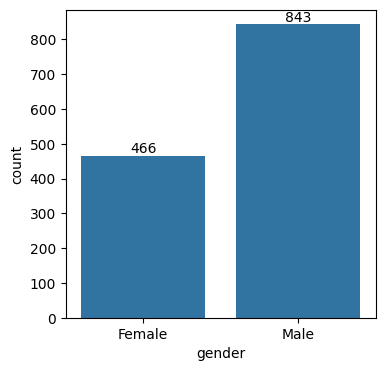

In [42]:
plt.figure(figsize=(4,4))
a = sns.countplot(df,x='gender')
a.bar_label(a.containers[0]) #this one doubt
plt.show()

2. plot the female and male count in each pclass

<Axes: xlabel='gender', ylabel='count'>

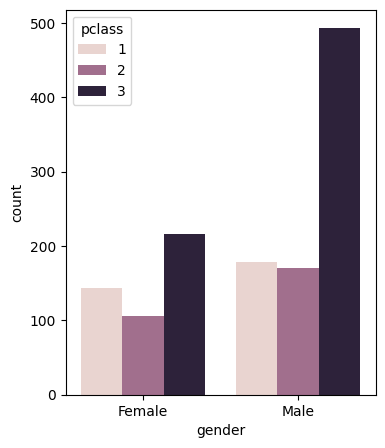

In [44]:
plt.figure(figsize=(4,5))
a = sns.countplot(df,x='gender',hue='pclass')
a

2. plot the female and male count in each survival_status

1. plot the companion_type count

1. plot the companion_type count in each gender

1. plot the companion_type count in each pclass

1. plot the companion_type count in each survival_status

1. plot the age_category count in each gender


1. plot the age_category count in each pclass

1. plot the age_category count in each survival_status


1. plot the embarked count in each gender

1. plot the embarked count in each survival_status


1. plot the embarked count in each pclass

2. plot the distribution of fare

3. plot the distribution of age

4. plot the percentage of passengers in each pclass

4. plot the percentage of passengers in each age_category

plot the spread of data in age_column wrt fare_column

plot the trend of age wrt fare

plot the trend of fare wrt pclass

find the outlier in fare,age

 get the co-relation for all numerical columns using heatmap


survival_rate of gender in each pclass
avg_age of gender in each pclass
avg_fare of gender in each pclass



survival_rate of gender in each age_category
survival_rate of companion_type in each age_category
